In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

100%|██████████| 26.4M/26.4M [00:03<00:00, 7.96MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 113kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 2.14MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.85MB/s]


In [4]:
image, label = train_dataset[0]
print(image.shape)
print(len(train_dataset))


torch.Size([1, 28, 28])
60000


In [5]:
image, label = test_dataset[0]
print(image.shape)
print(len(test_dataset))


torch.Size([1, 28, 28])
10000


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [8]:
from torchsummary import summary
import torch

model = CNNClassifier()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print('Name: THEJESWARAN M')
print('Register Number: 212223240168')

summary(model, input_size=(1, 28, 28), device=str(device))

Name: THEJESWARAN M
Register Number: 212223240168
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Linear-7                  [-1, 128]         401,536
              ReLU-8                  [-1, 128]               0
           Dropout-9                  [-1, 128]               0
           Linear-10                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass 

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
def train_model(model, train_loader, num_epochs=3):

    model.train()

    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print('Name: THEJESWARAN M')
        print('Register Number: 212223240168')
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')


In [11]:
train_model(model, train_loader)


Name: THEJESWARAN M
Register Number: 212223240168
Epoch [1/3], Loss: 0.4488
Name: THEJESWARAN M
Register Number: 212223240168
Epoch [2/3], Loss: 0.2956
Name: THEJESWARAN M
Register Number: 212223240168
Epoch [3/3], Loss: 0.2469


In [ ]:
def test_model(model, test_loader):

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print('Name: THEJESWARAN M')
    print('Register Number: 212223240168')
    print(f'Test Accuracy: {accuracy:.4f}')

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))

    print('Name: THEJESWARAN M')
    print('Register Number: 212223240168')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=test_dataset.classes,
                yticklabels=test_dataset.classes)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print('Name: THEJESWARAN M')
    print('Register Number: 212223240168')
    print("Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=test_dataset.classes))

Name: THEJESWARAN M
Register Number: 212223240168
Test Accuracy: 0.9077
Name: THEJESWARAN M
Register Number: 212223240168


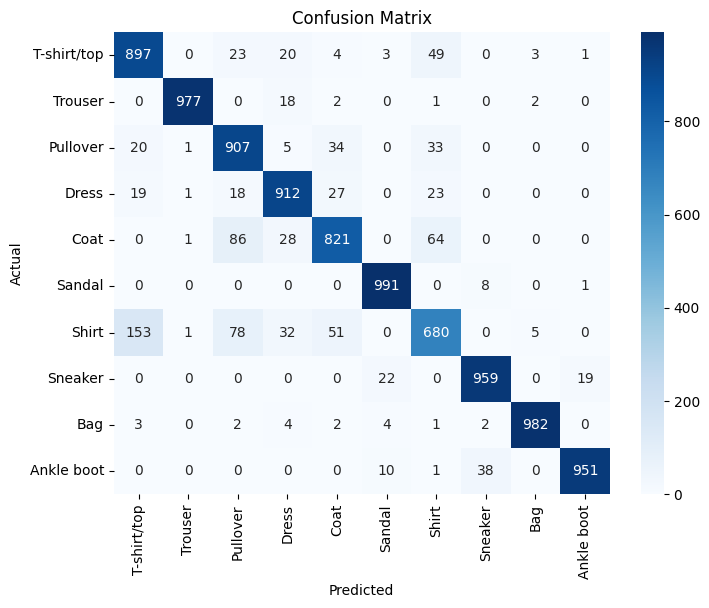

Name: THEJESWARAN M
Register Number: 212223240168
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.90      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.81      0.91      0.86      1000
       Dress       0.89      0.91      0.90      1000
        Coat       0.87      0.82      0.85      1000
      Sandal       0.96      0.99      0.98      1000
       Shirt       0.80      0.68      0.73      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
test_model(model, test_loader)

In [ ]:
import matplotlib.pyplot as plt

def predict_image(model, image_index, dataset):

    model.eval()

    image, label = dataset[image_index]

    image = image.to(device)

    with torch.no_grad():
        output = model(image.unsqueeze(0))
        _, predicted = torch.max(output, 1)

    class_names = dataset.classes

    print('Name: THEJESWARAN M')
    print('Register Number: 212223240168')

    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f'Actual: {class_names[label]}\nPredicted: {class_names[predicted.item()]}')
    plt.axis("off")
    plt.show()

    print(f'Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}')

Name: THEJESWARAN M
Register Number: 212223240168


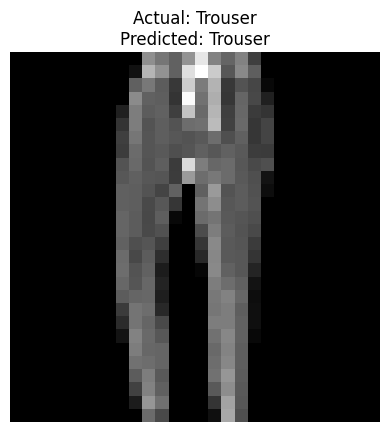

Actual: Trouser, Predicted: Trouser


In [ ]:
predict_image(model, image_index=80, dataset=test_dataset)